# 06. 최종 모델

03·04에서 고른 설정을 그대로 써서 2006–2025년 전체로 다시 학습하고, 서비스가 읽을 artifact로 저장한다. 설정은 여기서 바꾸지 않는다.

| 출력 | 5일 | 20일 | 60일 | 근거 |
|---|---|---|---|---|
| 예측 가격(로그수익률) | LightGBM | LightGBM | Ridge | 03: 개발 구간 RMSE 최저. Naive보다는 RMSE가 커서, 대시보드에 Naive 대비 성적을 함께 적는다 |
| 상승 확률·구매 신호 | ○ | ○ | ○ | 03: LightGBM 분류 + 확률 수축 + 신호 임계값 |
| 80% 가격 범위·위험 수준 | ○ | ○ | ○ | 04: HAR 변동성. 범위는 예측 가격을 가운데에 둔다 |

2026년은 **사후 확인** 구간이다. 이전 연구에서 이미 본 기간이라 미사용 평가셋이 아니다. 진짜 평가는 모델을 동결한 뒤 매일 쌓이는 실시간 예측(`kind='live'`)이다.

In [1]:
import subprocess

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import common
from coffee.config import ARTIFACTS_DIR, HORIZONS
from coffee.evaluate import direction_metrics, fold_rows, metrics
from coffee.features import ALL_FEATURES, build_dataset, trading_sessions
from coffee.models import (RETURN_ALGORITHMS, Z80, LightGBMClassifier, RidgeModel, ShrunkProbability, buy_signal,
                           load_bundle, price_range, return_model, save_bundle)
from coffee.sources import load_sources

data = build_dataset(load_sources())
direction_choice = {int(h): v for h, v in common.load_result("direction_selection").items()}
return_choice = {int(h): v for h, v in common.load_result("return_selection").items()}
vol_choice = {int(h): v for h, v in common.load_result("volatility_selection").items()}
FINAL_YEAR = 2026  # fold_rows(…, 2026): 학습 = 2006–2025, 평가 = 목표일이 확인된 2026년 행
VERSION = "2026-10-04"  # 수익률 예측과 5일 범위를 더한 모델 (이전 버전은 git 태그로 보관)
print(f"자료: {data.index[0]:%Y-%m-%d} ~ {data.index[-1]:%Y-%m-%d}")

자료: 2005-01-03 ~ 2026-10-02


## 1. 2006–2025년으로 다시 학습

In [2]:
direction, returns, volatility, train_rows = {}, {}, {}, []
for h in HORIZONS:
    choice = direction_choice[h]
    assert choice["model"] == "LightGBM분류(약한 정규화)"  # 03의 선택이 바뀌면 여기서 멈춘다
    fit, _ = fold_rows(data, ALL_FEATURES, h, FINAL_YEAR, FINAL_YEAR)
    y = data[f"y_{h}"].to_numpy()[fit]
    model = ShrunkProbability(LightGBMClassifier(choice["features"], n_estimators=200, min_child_samples=80),
                              choice["shrink"])
    direction[h] = model.fit(data, fit, y)
    returns[h] = return_model(return_choice[h]["model"], return_choice[h]["features"], h).fit(data, fit, y)
    train_rows += [{"모델": "방향", "지평": h, "학습 행": len(fit), "시작": data.index[fit[0]],
                    "끝": data.index[fit[-1]], "학습 구간 상승 비율": model.base_},
                   {"모델": f"수익률({return_choice[h]['model']})", "지평": h, "학습 행": len(fit),
                    "시작": data.index[fit[0]], "끝": data.index[fit[-1]], "학습 구간 상승 비율": np.nan}]
    assert vol_choice[h]["model"] == "HAR"
    fit, _ = fold_rows(data, ALL_FEATURES, h, FINAL_YEAR, FINAL_YEAR, target=f"v_{h}")
    volatility[h] = RidgeModel(vol_choice[h]["har_features"], alpha=1).fit(data, fit, data[f"v_{h}"].to_numpy()[fit])
    train_rows.append({"모델": "변동성", "지평": h, "학습 행": len(fit), "시작": data.index[fit[0]],
                       "끝": data.index[fit[-1]], "학습 구간 상승 비율": np.nan})
pd.DataFrame(train_rows).set_index(["모델", "지평"]).round(3)

,,학습 행,시작,끝,학습 구간 상승 비율
모델,지평,,,,
방향,5,4844,2006-01-03,2025-12-23,0.494
수익률(LightGBM),5,4844,2006-01-03,2025-12-23,NaN
변동성,5,4860,2006-01-03,2025-12-23,NaN
방향,20,4829,2006-01-03,2025-12-02,0.486
수익률(LightGBM),20,4829,2006-01-03,2025-12-02,NaN
변동성,20,4845,2006-01-03,2025-12-02,NaN
방향,60,4789,2006-01-03,2025-10-06,0.499
수익률(Ridge),60,4789,2006-01-03,2025-10-06,NaN
변동성,60,4728,2006-01-03,2025-10-06,NaN


## 2. 저장하고 다시 읽기

`model_artifacts/<버전>/direction`, `…/return`, `…/volatility`에 지평별 모델과 `metadata.json`을 쓴다. metadata에는 피처, 수축 계수, 임계값, 범위 배율, 학습 구간, 코드 커밋과 파일 해시가 들어간다. 수익률 모델은 지평마다 종류가 달라서 모델 이름(`algorithm`)과 개발·보류 구간 성적을 지평별로 적는다. 대시보드가 이 값을 읽어 보여 준다. 다시 읽은 모델이 같은 예측을 내는지 확인한다.

In [3]:
target = ARTIFACTS_DIR / VERSION
commit = subprocess.run(["git", "rev-parse", "--short", "HEAD"], capture_output=True, text=True, cwd=common.ROOT).stdout.strip()
shared = {"version": VERSION, "train_end": "2025-12-31", "data_end": data.index[-1], "code_commit": commit,
          "train_rows": {f"{row['모델']}_{row['지평']}": row["학습 행"] for row in train_rows}}
save_bundle(target / "direction", direction, {
    **shared, "kind": "direction", "algorithm": "LightGBM 분류 + 확률 수축",
    "horizons": {str(h): {"features": c["features"], "shrink": c["shrink"], "threshold": c["threshold"],
                          "base_rate": direction[h].base_} for h, c in direction_choice.items()},
})
save_bundle(target / "return", returns, {
    **shared, "kind": "return",
    "horizons": {str(h): {"features": c["features"], "model": c["model"], "algorithm": RETURN_ALGORITHMS[c["model"]],
                          "dev": c["dev"], "holdout": c["holdout"]} for h, c in return_choice.items()},
})
save_bundle(target / "volatility", volatility, {
    **shared, "kind": "volatility", "algorithm": "HAR (Ridge, alpha=1)",
    "horizons": {str(h): {"features": vol_choice[h]["har_features"], "interval_multiplier": vol_choice[h]["interval_multiplier"],
                          "z": Z80} for h in HORIZONS},
})

recent = np.arange(len(data) - 250, len(data))
for kind, models in (("direction", direction), ("return", returns), ("volatility", volatility)):
    loaded, _ = load_bundle(target / kind)
    assert all(np.array_equal(loaded[h].predict(data, recent), models[h].predict(data, recent)) for h in HORIZONS)
{path.relative_to(target).as_posix(): f"{path.stat().st_size / 1024:.0f} KB" for path in sorted(target.rglob("*.*"))}

{'direction/h20.joblib': '184 KB',
 'direction/h5.joblib': '184 KB',
 'direction/h60.joblib': '184 KB',
 'direction/metadata.json': '4 KB',
 'return/h20.joblib': '120 KB',
 'return/h5.joblib': '121 KB',
 'return/h60.joblib': '1 KB',
 'return/metadata.json': '2 KB',
 'volatility/h20.joblib': '1 KB',
 'volatility/h5.joblib': '1 KB',
 'volatility/h60.joblib': '1 KB',
 'volatility/metadata.json': '1 KB'}

## 3. 2026년 사후 확인

2026년 1월부터 목표일 가격이 확인된 행까지 평가한다. 지평이 길수록 평가 행이 적고, 겹치는 목표 때문에 실제 독립 표본은 더 적다. 개발·보류 구간 결과와 방향이 같은지만 본다.

In [4]:
rows = []
for h in HORIZONS:
    _, test = fold_rows(data, ALL_FEATURES, h, FINAL_YEAR, FINAL_YEAR)
    prob = direction[h].predict(data, test)
    d = direction_metrics(data[f"y_{h}"].to_numpy()[test], prob, base_rate=direction[h].base_,
                          threshold=direction_choice[h]["threshold"])
    rows.append({"지평": h, "평가 행": d["n"], "기준일": f"{data.index[test[0]]:%m-%d}~{data.index[test[-1]]:%m-%d}",
                 "실제 상승 비율": d["up_rate"], "AUC": d["auc"], "Brier": d["brier"], "기본 비율 Brier": d["base_brier"],
                 "신호 빈도": d["coverage"], "신호 적중률": d["precision"]})
forward_direction = pd.DataFrame(rows).set_index("지평")
forward_direction.round(3)

,평가 행,기준일,실제 상승 비율,AUC,Brier,기본 비율 Brier,신호 빈도,신호 적중률
지평,,,,,,,,
5,184,01-02~09-25,0.435,0.512,0.249,0.249,0.380,0.543
20,169,01-02~09-03,0.479,0.390,0.263,0.250,0.201,0.412
60,129,01-02~07-09,0.465,0.698,0.232,0.250,0.310,0.775


2026년 방향 예측은 지평마다 엇갈렸다. 5일은 AUC 0.51로 오르내림을 구분하지 못했고, 20일은 0.39로 오히려 반대로 짚었다(신호 적중률 41%). 60일은 AUC 0.70, 신호 적중률 78%(신호 빈도 31%)로 좋았지만 평가 행이 129개이고 60일 목표가 서로 크게 겹쳐 독립된 표본은 몇 개 되지 않는다. 보류 구간의 약한 우위(AUC 0.54~0.60)가 해마다 유지되지는 않는다. 설정은 2026년 결과를 보고 바꾸지 않는다. 대신 대시보드에 확률과 함께 실제 적중 기록을 보여 준다.

In [5]:
rows = []
for h in HORIZONS:
    _, test = fold_rows(data, ALL_FEATURES, h, FINAL_YEAR, FINAL_YEAR)
    actual, pred = data[f"y_{h}"].to_numpy()[test], returns[h].predict(data, test)
    m, naive = metrics(actual, pred), metrics(actual, np.zeros_like(actual))
    rows.append({"지평": h, "모델": return_choice[h]["model"], "평가 행": len(test),
                 "RMSE Naive 대비 %": 100 * (m["rmse"] / naive["rmse"] - 1), "방향 정확도": m["direction_acc"],
                 "예측 상승 비율": float(np.mean(pred > 0)), "실제 상승 비율": float(np.mean(actual > 0))})
forward_return = pd.DataFrame(rows).set_index("지평")
forward_return.round(3)

,모델,평가 행,RMSE Naive 대비 %,방향 정확도,예측 상승 비율,실제 상승 비율
지평,,,,,,
5,LightGBM,184,0.029,0.543,0.620,0.435
20,LightGBM,169,-0.876,0.544,0.604,0.479
60,Ridge,129,-4.379,0.659,0.682,0.465


수익률 예측은 2026년에 개발·보류 구간보다 나았다. RMSE는 Naive 대비 5일 +0.0%, 20일 −0.9%, 60일 −4.4%이고, 방향 정확도는 54% / 54% / 66%다. 하지만 60일 방향 정확도는 보류 구간에서 38%였다. 기간마다 이만큼 흔들리므로 한 해의 좋은 결과를 모델이 나아진 증거로 볼 수 없다. 세 모델 모두 상승을 60~68%의 날에 예측했는데 실제 상승 비율은 44~48%였다는 점도 기록해 둔다.

In [6]:
def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))


rows = []
for h in HORIZONS:
    _, test = fold_rows(data, ALL_FEATURES, h, FINAL_YEAR, FINAL_YEAR, target=f"v_{h}")
    actual, pred = data[f"v_{h}"].to_numpy()[test], volatility[h].predict(data, test)
    # 현재가 1을 기준으로 예측 가격을 가운데에 둔 범위
    low, high = price_range(1.0, pred, h, vol_choice[h]["interval_multiplier"], center=returns[h].predict(data, test))
    ratio = np.exp(data[f"y_{h}"].to_numpy()[test])
    valid = ~np.isnan(ratio)
    rows.append({"지평": h, "평가 행": len(test), "RMSE HAR": rmse(actual, pred),
                 "RMSE 직전 변동성": rmse(actual, data[f"log_vol_{h}"].to_numpy()[test]),
                 "80% 범위 적중률": float(np.mean((ratio[valid] >= low[valid]) & (ratio[valid] <= high[valid])))})
forward_volatility = pd.DataFrame(rows).set_index("지평")
forward_volatility.round(4)

,평가 행,RMSE HAR,RMSE 직전 변동성,80% 범위 적중률
지평,,,,
5,184,0.4750,0.6036,0.7717
20,169,0.3550,0.4346,0.6391
60,129,0.3887,0.3776,0.7752


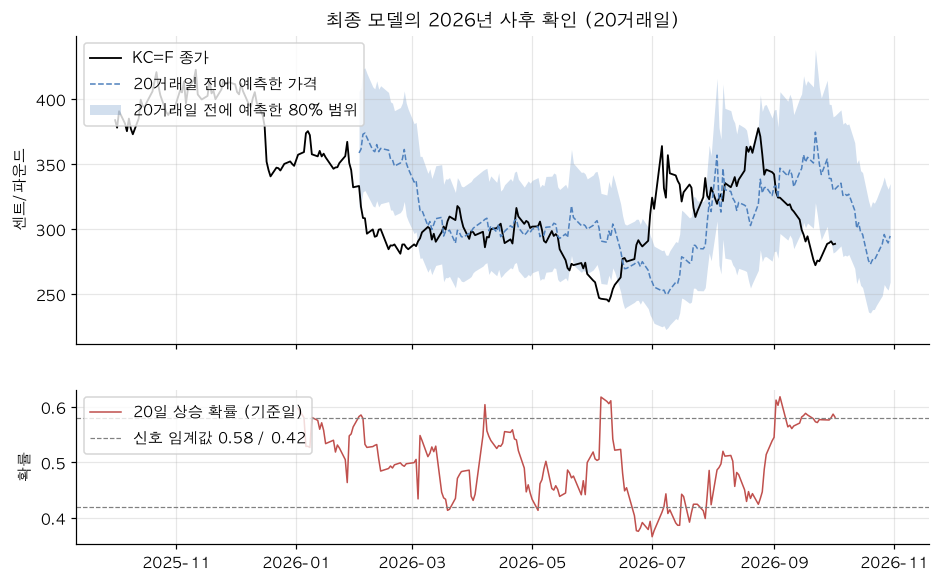

In [7]:
H = 20
origins = np.flatnonzero((data.index >= "2026-01-01") & data["log_vol_20"].notna().to_numpy())
axis = data.index.append(trading_sessions(data.index[-1] + pd.Timedelta(days=1), data.index[-1] + pd.Timedelta(days=120)))
target_dates = axis[origins + H]
close = data["close"].to_numpy()[origins]
predicted_return = returns[H].predict(data, origins)
low, high = price_range(close, volatility[H].predict(data, origins), H, vol_choice[H]["interval_multiplier"],
                        center=predicted_return)
prob = direction[H].predict(data, origins)
threshold = direction_choice[H]["threshold"]

fig, (top, bottom) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
recent_close = data.loc["2025-10-01":, "close"]
top.plot(recent_close.index, recent_close, color="black", lw=1.2, label="KC=F 종가")
top.plot(target_dates, close * np.exp(predicted_return), color="#4f81bd", lw=1, ls="--", label="20거래일 전에 예측한 가격")
top.fill_between(target_dates, low, high, color="#4f81bd", alpha=0.25, lw=0, label="20거래일 전에 예측한 80% 범위")
top.set(ylabel="센트/파운드", title="최종 모델의 2026년 사후 확인 (20거래일)")
top.legend(loc="upper left")
bottom.plot(data.index[origins], prob, color="#c0504d", lw=1, label="20일 상승 확률 (기준일)")
bottom.axhline(threshold, color="gray", ls="--", lw=0.8)
bottom.axhline(1 - threshold, color="gray", ls="--", lw=0.8, label=f"신호 임계값 {threshold:.2f} / {1 - threshold:.2f}")
bottom.set(ylabel="확률")
bottom.legend(loc="upper left")
common.save_fig(fig, "final_forecast_2026.png")
plt.show()

변동성은 HAR이 직전 변동성보다 5일 21%, 20일 18% RMSE가 낮았다. 개발·보류 구간과 같은 결론이다. 60일은 보류 구간처럼 3% 나빴다. 예측 가격을 가운데에 둔 80% 범위의 적중률은 5일 77%, 20일 64%, 60일 78%로 목표보다 낮다. 그림에서 1–2월 급락과 6–7월 급등이 범위를 벗어났다. 범위는 급변을 미리 알려 주지 못하고, 급변 뒤에 넓어진다.

## 4. 최신 기준일의 예측

서비스가 매일 계산할 값과 같은 방식이다. 위험 수준은 최근 3년(756거래일) 동안의 예측 변동성 가운데 오늘 값의 백분위다(04의 결론).

In [8]:
origin = len(data) - 1
rows = []
for h in HORIZONS:
    features = direction_choice[h]["features"]
    p_up = float(direction[h].predict(data, [origin])[0])
    r_hat = float(returns[h].predict(data, [origin])[0])
    log_vol = volatility[h].predict(data, [origin])
    history = volatility[h].predict(data, np.arange(origin - 755, origin + 1))
    close = data["close"].iloc[origin]
    low, high = price_range(close, log_vol, h, vol_choice[h]["interval_multiplier"], center=r_hat)
    rows.append({"지평": h, "기준일": data.index[origin], "목표일": axis[origin + h], "현재가": close,
                 "예측 수익률": r_hat, "예측 가격": close * np.exp(r_hat), "80% 하단": float(low[0]), "80% 상단": float(high[0]),
                 "상승 확률": p_up, "신호": buy_signal([p_up], direction_choice[h]["threshold"])[0],
                 "예측 변동성(연율)": float(np.exp(log_vol[0]) * np.sqrt(252)),
                 "최근 3년 백분위": float((history <= log_vol[0]).mean()),
                 "결측 피처 수": int(data[features].iloc[origin].isna().sum())})
today = pd.DataFrame(rows).set_index("지평")
today.round(3)

,기준일,목표일,현재가,예측 수익률,예측 가격,80% 하단,80% 상단,상승 확률,신호,예측 변동성(연율),최근 3년 백분위,결측 피처 수
지평,,,,,,,,,,,,
5,2026-10-02,2026-10-09,288.75,0.006,290.533,272.088,310.228,0.513,hold,0.303,0.536,0
20,2026-10-02,2026-10-30,288.75,0.021,294.835,259.388,335.126,0.581,buy,0.335,0.512,0
60,2026-10-02,2026-12-29,288.75,0.028,297.012,242.795,363.336,0.634,buy,0.339,0.536,0


2026-10-02 기준으로 세 지평 모두 소폭 상승을 예측했다(로그수익률 5 / 20 / 60일 +0.6% / +2.1% / +2.8%, 예측 가격 290.5 / 294.8 / 297.0). 80% 범위는 272–310, 259–335, 243–363으로, 범위의 폭에 비하면 예측한 상승은 작다. 상승 확률은 20일 0.58, 60일 0.63으로 기준을 넘어 '지금 구매(buy)' 신호가 나왔다. 위의 성적을 보면 이 예측과 신호를 그대로 믿을 근거는 약하다. 예측 변동성은 연율 30~34%로 최근 3년 중 중간(51~54 백분위)이다.

In [9]:
common.save_result("final_model", {
    "version": VERSION, "code_commit": commit, "train": train_rows,
    "forward_2026": {"direction": forward_direction.round(4).reset_index().to_dict("records"),
                     "return": forward_return.round(4).reset_index().to_dict("records"),
                     "volatility": forward_volatility.round(4).reset_index().to_dict("records")},
    "latest": today.round(4).reset_index().to_dict("records"),
})

## 정리

- 최종 모델: 방향은 LightGBM 분류 + 확률 수축, 수익률은 5·20일 LightGBM·60일 Ridge(변동성 정규화), 변동성은 세 지평 모두 HAR. `model_artifacts/2026-10-04/`에 저장했다. 이전 버전(`2026-10-03`, `2026-10-03b`)은 git 태그로만 남겼다.
- 수익률 예측은 개발·보류 구간에서 Naive보다 RMSE가 컸다. 그래도 서비스에 보여 주고, 대시보드에 Naive 대비 성적과 실제 적중 기록을 함께 적는다.
- 2026년 사후 확인에서 5·20일 변동성 예측은 기준선보다 나았지만, 방향·수익률 예측은 기간마다 결과가 크게 달랐다(20일 상승 확률 AUC 0.39, 60일 수익률 방향 정확도 보류 38% → 2026년 66%).
- 이 버전으로 모델을 동결한다(git 태그 `model-2026-10-04`). 이후 매일 저장되는 live 예측이 처음으로 보지 않은 자료에 대한 평가다.